First 5 rows:
   Unnamed: 0                track_id                 artists  \
0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       149610     False   
2              To Begin Again          57       210826

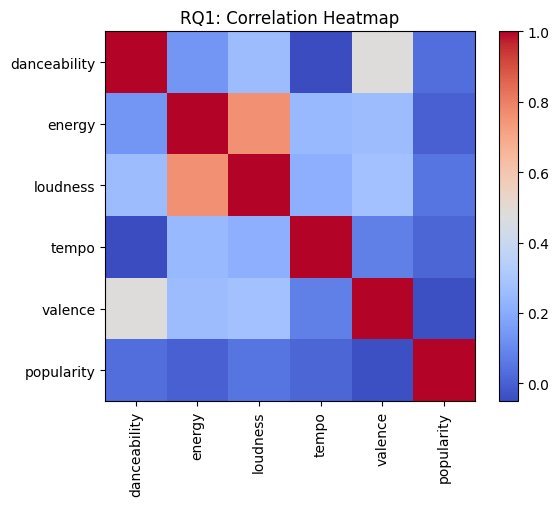


RQ2: Danceability vs Popularity
        danceability     popularity
count  113999.000000  113999.000000
mean        0.566801      33.238827
std         0.173543      22.304959
min         0.000000       0.000000
25%         0.456000      17.000000
50%         0.580000      35.000000
75%         0.695000      50.000000
max         0.985000     100.000000


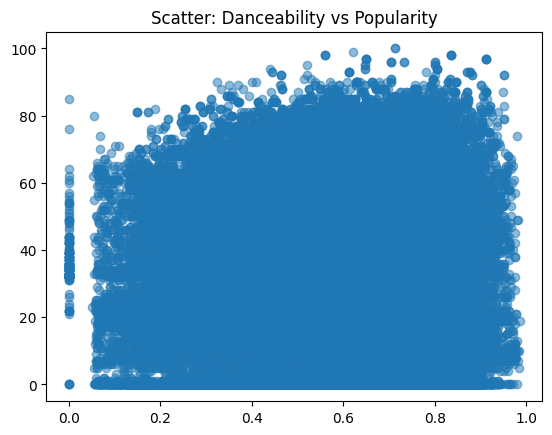

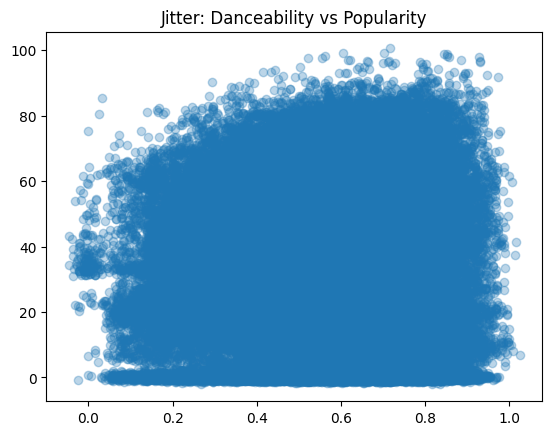


RQ3: Energy vs Popularity
              energy     popularity
count  113999.000000  113999.000000
mean        0.641383      33.238827
std         0.251530      22.304959
min         0.000000       0.000000
25%         0.472000      17.000000
50%         0.685000      35.000000
75%         0.854000      50.000000
max         1.000000     100.000000


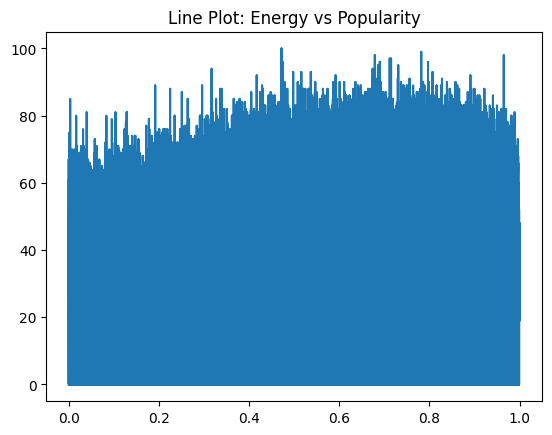


RQ4: Tempo vs Popularity


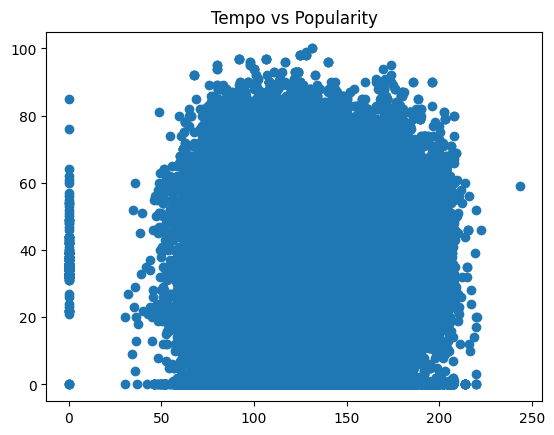


RQ5: Model Comparison Table
               Model        MAE         MSE
0  Linear Regression  18.666725  491.322358
1      Decision Tree  13.776615  461.322997
2                KNN  15.870202  425.631423


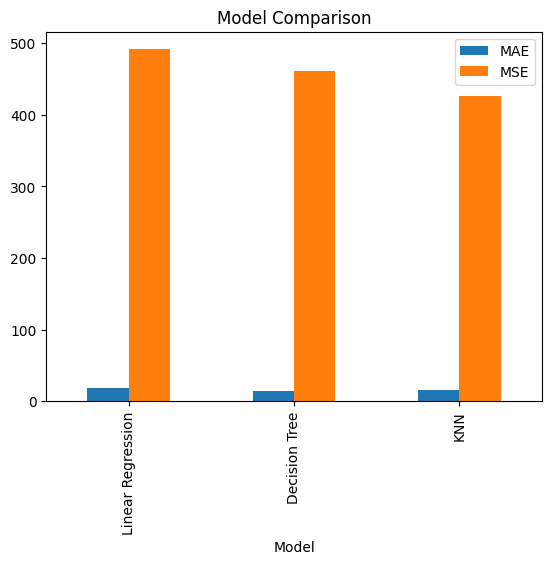


RQ6: Popularity Distribution
count    113999.000000
mean         33.238827
std          22.304959
min           0.000000
25%          17.000000
50%          35.000000
75%          50.000000
max         100.000000
Name: popularity, dtype: float64


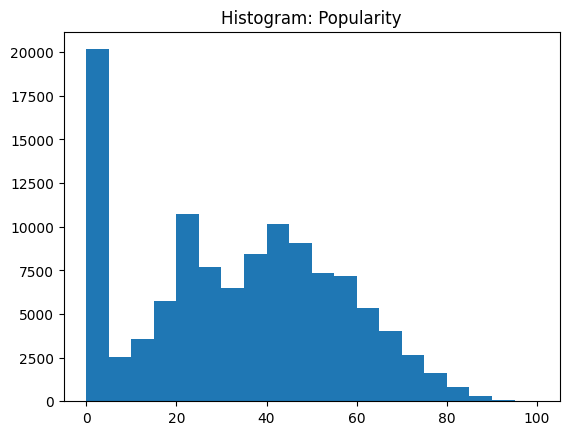


RQ7: Prediction Results


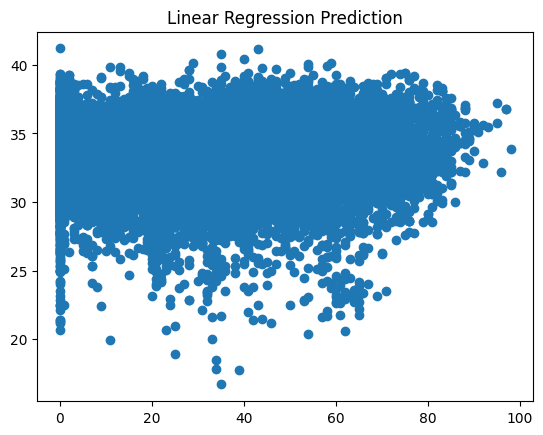

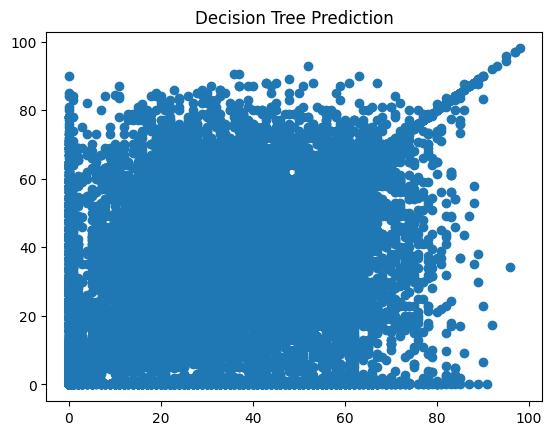

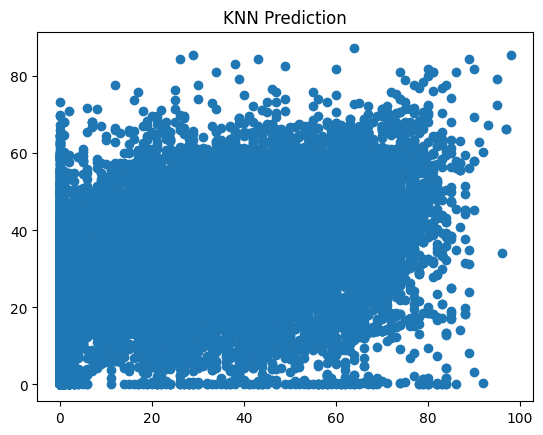

In [4]:
# =========================
# STEP 1: IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# STEP 2: LOAD DATA
# =========================
df = pd.read_csv("/content/spotify_tracks.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

# =========================
# STEP 3: CLEAN DATA
# =========================
df = df.dropna()
df = df.drop_duplicates()

print("\nAfter Cleaning Shape:")
print(df.shape)

# =========================
# STEP 4: FEATURES & TARGET
# =========================
features = ['danceability', 'energy', 'loudness', 'tempo', 'valence']
X = df[features]
y = df['popularity']

# =========================
# STEP 5: TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================================
# RQ1: CORRELATION ANALYSIS
# =========================================================
print("\nRQ1: Correlation Table")

corr = df[features + ['popularity']].corr()
print(corr)

plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("RQ1: Correlation Heatmap")
plt.show()

# =========================================================
# RQ2: DANCEABILITY ANALYSIS
# =========================================================
print("\nRQ2: Danceability vs Popularity")

print(df[['danceability','popularity']].describe())

plt.scatter(df['danceability'], df['popularity'], alpha=0.5)
plt.title("Scatter: Danceability vs Popularity")
plt.show()

# Jitter plot
x_jitter = df['danceability'] + np.random.normal(0, 0.02, len(df))
y_jitter = df['popularity'] + np.random.normal(0, 0.5, len(df))

plt.scatter(x_jitter, y_jitter, alpha=0.3)
plt.title("Jitter: Danceability vs Popularity")
plt.show()

# =========================================================
# RQ3: ENERGY ANALYSIS (LINE PLOT)
# =========================================================
print("\nRQ3: Energy vs Popularity")

print(df[['energy','popularity']].describe())

temp = df.sort_values('energy')

plt.plot(temp['energy'], temp['popularity'])
plt.title("Line Plot: Energy vs Popularity")
plt.show()

# =========================================================
# RQ4: TEMPO ANALYSIS
# =========================================================
print("\nRQ4: Tempo vs Popularity")

plt.scatter(df['tempo'], df['popularity'])
plt.title("Tempo vs Popularity")
plt.show()

# =========================================================
# RQ5: MACHINE LEARNING MODELS
# =========================================================

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)

# Decision Tree
dt = DecisionTreeRegressor()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_pred)
dt_mse = mean_squared_error(y_test, dt_pred)

# KNN
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

knn_mae = mean_absolute_error(y_test, knn_pred)
knn_mse = mean_squared_error(y_test, knn_pred)

print("\nRQ5: Model Comparison Table")

results = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "KNN"],
    "MAE": [lr_mae, dt_mae, knn_mae],
    "MSE": [lr_mse, dt_mse, knn_mse]
})

print(results)

results.set_index("Model").plot(kind='bar')
plt.title("Model Comparison")
plt.show()

# =========================================================
# RQ6: POPULARITY DISTRIBUTION
# =========================================================
print("\nRQ6: Popularity Distribution")

print(df['popularity'].describe())

plt.hist(df['popularity'], bins=20)
plt.title("Histogram: Popularity")
plt.show()

# =========================================================
# RQ7: ACTUAL vs PREDICTED
# =========================================================
print("\nRQ7: Prediction Results")

plt.scatter(y_test, lr_pred)
plt.title("Linear Regression Prediction")
plt.show()

plt.scatter(y_test, dt_pred)
plt.title("Decision Tree Prediction")
plt.show()

plt.scatter(y_test, knn_pred)
plt.title("KNN Prediction")
plt.show()